In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import least_squares

In [3]:
mpl.rcParams['figure.dpi'] = 150

In [107]:
def read_transition(filename, mu_min, column_mu=0, columns_sigma=(1,2), skiprows=0, 
                    least_spacing=0.01):
    columns = (column_mu,) + columns_sigma
    data = np.loadtxt(filename, usecols=columns, skiprows=skiprows)
    answer = [[data[0,0], (data[0,1] + data[0,2]) / 2]]
    for i in range(1, len(data)):
        if data[i,0] - answer[-1][0] >= least_spacing:
            answer.append([data[i,0], (data[i,1] + data[i,2]) / 2])

    data_filtered = data[data[:,0] >= mu_min]
    answer_filtered = [[data_filtered[0,0], (data_filtered[0,1] + data_filtered[0,2]) / 2]]
    for i in range(1, len(data_filtered)):
        if data_filtered[i,0] - answer_filtered[-1][0] >= least_spacing:
            answer_filtered.append([data_filtered[i,0], (data_filtered[i,1] + data_filtered[i,2]) / 2])
    return np.array(answer), np.array(answer_filtered)

In [108]:
def read_all_transitions(mu_min, N_list, path, eps, lda, tol_fixed_point, c, T, 
                         colum_mu=0, columns_sigma=(1,2), skiprows=0, least_spacing=0.01):
    all_data = {}
    all_data_filtered = {}
    for N in N_list:
        filename = f'{path}/Lotka-Volterra_transition_div_epsilon_{eps}_Partially_AsymGauss_lambda_{lda}_tol_{tol_fixed_point}_N_{N}_c_{c}_T_{T}.txt'
        data, data_filtered = read_transition(filename, mu_min, column_mu=colum_mu, columns_sigma=columns_sigma, 
                                              skiprows=skiprows, least_spacing=least_spacing)
        all_data[N] = data
        all_data_filtered[N] = data_filtered
    return all_data, all_data_filtered

In [98]:
def residuals(A, c, all_data, unique_A=False, min_N=0):
    counter = 0
    res = []
    for N in all_data:
        if N > min_N:
            data = all_data[N]
            mu_values = data[:,0]
            observed_sigma = data[:,1]
            if unique_A:
                predicted_sigma = np.sqrt(1 + 2 * mu_values * np.sqrt(c)) / (A* np.sqrt(np.log(N))) 
            else:
                predicted_sigma = np.sqrt(1 + 2 * mu_values * np.sqrt(c)) / (A[counter]* np.sqrt(np.log(N)))
                counter += 1
            res.extend(observed_sigma - predicted_sigma)
    return np.array(res)

In [83]:
def make_fit(c, all_data, initial_guess, unique_A=False, min_N=0):
    result = least_squares(residuals, initial_guess, args=(c, all_data, unique_A, min_N))
    print("Optimized parameters:", result.x)
    print("Cost function value:", result.cost / len(all_data.keys()))
    return result.x

In [116]:
def plot_fits(all_data, min_mu, optimized_A, c, unique_A=False):
    plt.figure()
    colors = plt.cm.viridis(np.linspace(0, 1, len(all_data)))
    for idx, N in enumerate(all_data):
        data = all_data[N]
        mu_values = data[:,0]
        mu_values_plot = np.linspace(min_mu, max(mu_values), 1000)
        observed_sigma = data[:,1]
        plt.scatter(mu_values, observed_sigma, label=f'N={N}', color=colors[idx], s=10)
        if unique_A:
            predicted_sigma = np.sqrt(1 + 2 * mu_values_plot * np.sqrt(c)) / (optimized_A * np.sqrt(np.log(N)))
        else:
            predicted_sigma = np.sqrt(1 + 2 * mu_values_plot * np.sqrt(c)) / (optimized_A[idx] * np.sqrt(np.log(N)))
        plt.plot(mu_values_plot, predicted_sigma, color=colors[idx])
    plt.xlabel(r'$\mu$')
    plt.ylabel(r'$\sigma$')
    plt.legend()
    plt.show()

In [85]:
eps = "0.0"
lda = "1e-06"
N_list = [128, 256, 512, 1024, 2048, 4096]
c = "3.00"
T = "0.0"
tol_fixed_point = "1e-08"

path = "/media/david/Seagate Expansion Drive/Salva/Salva_Data_Investigacion/Grupo_de_investigacion/Ecology/Langevin/Results/"

In [113]:
mu_min = -0.2
all_data, all_data_filtered = read_all_transitions(mu_min, N_list, path, eps, lda, tol_fixed_point, c, T, 
                                                   least_spacing=0.03)

Optimized parameters: [0.87836476 0.90304061 0.92025392 0.9341507  0.94543257 0.95599412]
Cost function value: 0.000873336569681006


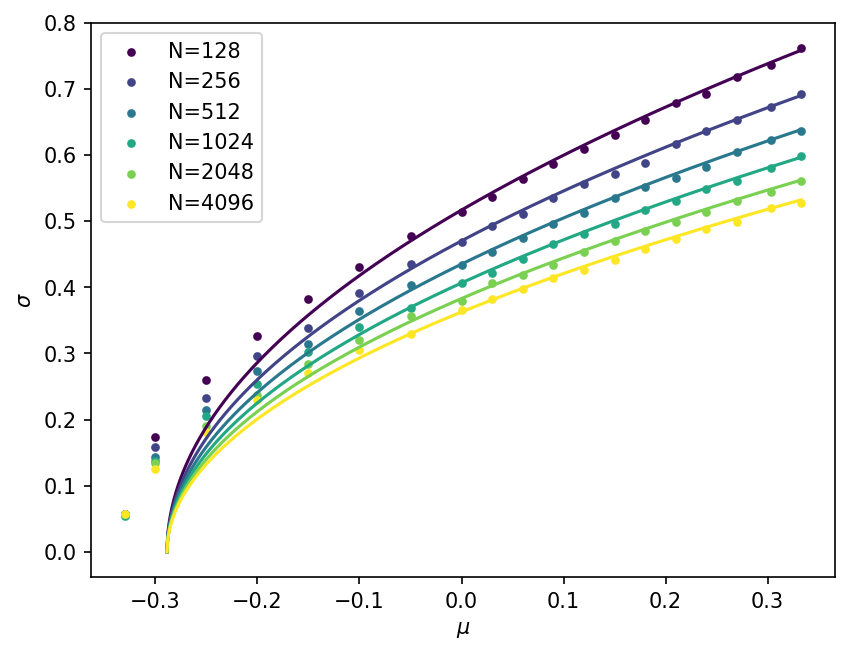

In [117]:
Ainit = [1.0 for _ in N_list]
optimized_A = make_fit(float(c), all_data_filtered, Ainit, unique_A=False)
min_mu_plot = -1.0 / (2 * np.sqrt(float(c)))
plot_fits(all_data, min_mu_plot, optimized_A, float(c), unique_A=False)

Optimized parameters: [0.94444394]
Cost function value: 0.0004232849570728656


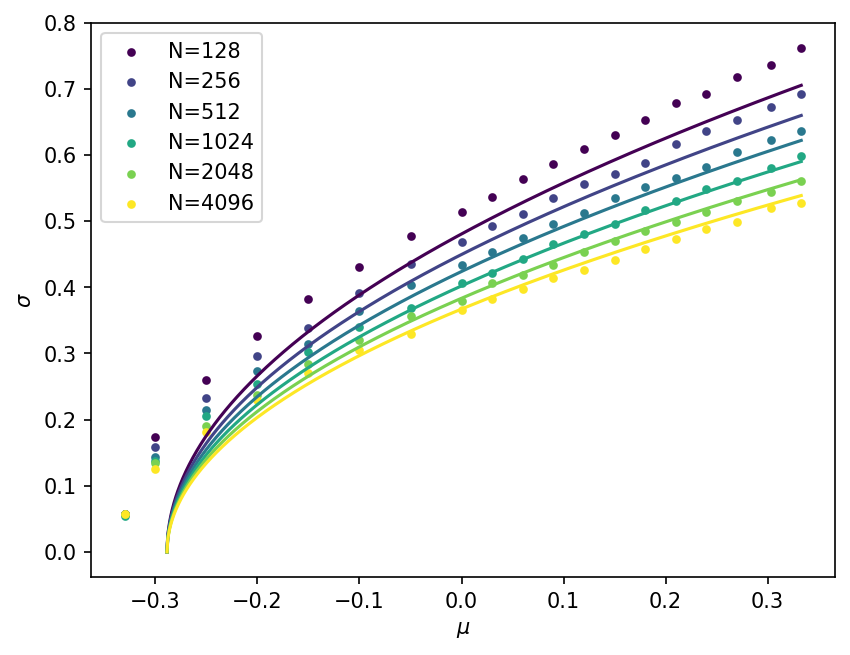

In [118]:
Ainit = 1.0
min_N = 512
optimized_A = make_fit(float(c), all_data_filtered, Ainit, unique_A=True, min_N=min_N)
min_mu_plot = -1.0 / (2 * np.sqrt(float(c)))
plot_fits(all_data, min_mu_plot, optimized_A, float(c), unique_A=True)